
# Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space

## Objective
Build a Variational Autoencoder (VAE) using the MNIST handwritten-digit dataset and learn a **2-dimensional latent space** that can be visualised on a graph.

This notebook follows the assignment requirements:

- Load and visualise the MNIST dataset.
- Build a VAE with a 2-dimensional latent space.
- Train the model for approximately **20 epochs**.
- Record **reconstruction loss** and **KL-divergence loss** separately.
- Plot the training losses.
- Pass test images through the encoder and create a coloured 2D latent-space scatter plot.
- Decode points from approximately **−3 to +3** into digit images.
- Display original and reconstructed images.
- Record short observations about clusters and smooth transitions.

> **Runtime note:** GPU is recommended, but the notebook can also run on a CPU. TensorFlow must be installed before running the notebook.



## Connection with the supplied practical instructions

The supplied practical notes mention the following VAE workflow on page 2:

1. Import libraries.
2. Load and display the MNIST dataset.
3. Build an autoencoder/VAE architecture.
4. Use a VAE loss containing reconstruction error and KL divergence.
5. Train the VAE for 20 epochs.
6. Plot the losses.
7. Reconstruct test images.
8. Visualise the VAE latent space.
9. Generate digits across the latent space.
10. Generate images from extreme latent points.

This notebook implements these steps directly for the assignment.


In [16]:

# If TensorFlow is not installed, run this in a separate notebook cell:
# %pip install tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist


# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


## 1. Load and prepare the MNIST dataset

In [3]:

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28, 1)
Test images: (10000, 28, 28, 1)
Training labels: (60000,)
Test labels: (10000,)


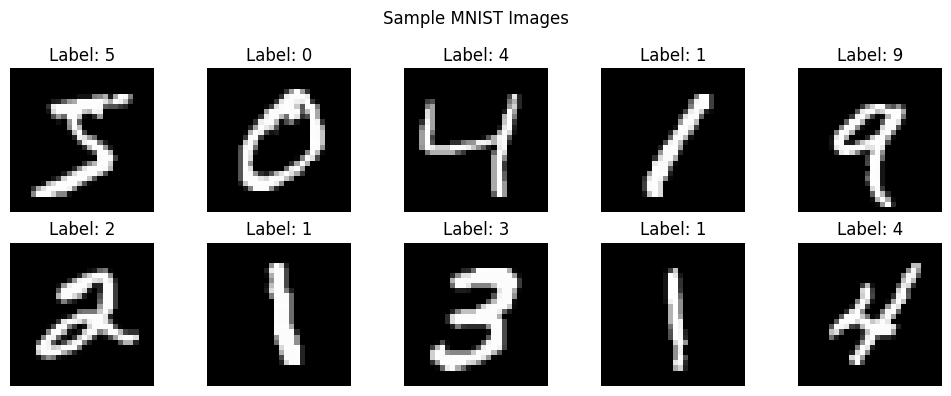

In [4]:

# Display a few original MNIST images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()



## 2. Set the basic parameters

A 2-dimensional latent space is used intentionally so that the encoded digits can be plotted on a 2D graph.


In [5]:

LATENT_DIM = 2
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

print("Latent dimension:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)


Latent dimension: 2
Batch size: 128
Epochs: 20


## 3. Build the encoder

In [6]:

class Encoder(Model):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.flatten = layers.Flatten()
        self.dense_1 = layers.Dense(256, activation="relu")
        self.dense_2 = layers.Dense(128, activation="relu")

        # These two layers produce the mean and log-variance
        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")

    def call(self, inputs):
        x = self.flatten(inputs)
        x = self.dense_1(x)
        x = self.dense_2(x)

        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)

        return z_mean, z_log_var


encoder = Encoder(LATENT_DIM)



## 4. Reparameterization trick

The encoder does not directly produce one fixed latent vector. It produces:

- `z_mean`: the mean of the latent distribution.
- `z_log_var`: the logarithm of the variance.

The reparameterization trick samples a latent vector using:

\[
z = \mu + \sigma 	imes \epsilon
\]

where:

- \(\mu\) is the mean.
- \(\sigma = e^{0.5 	imes 	ext{log variance}}\).
- \(\epsilon\) is random noise from a standard normal distribution.


In [7]:

def sample_latent_vector(z_mean, z_log_var):
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    standard_deviation = tf.exp(0.5 * z_log_var)
    return z_mean + standard_deviation * epsilon


## 5. Build the decoder

In [8]:

class Decoder(Model):
    def __init__(self):
        super().__init__()

        self.dense_1 = layers.Dense(128, activation="relu")
        self.dense_2 = layers.Dense(256, activation="relu")
        self.output_layer = layers.Dense(28 * 28, activation="sigmoid")
        self.reshape = layers.Reshape((28, 28, 1))

    def call(self, inputs):
        x = self.dense_1(inputs)
        x = self.dense_2(x)
        x = self.output_layer(x)
        return self.reshape(x)


decoder = Decoder()



## 6. Create the VAE model

The VAE contains two main parts:

1. **Encoder:** Converts an image into a latent representation.
2. **Decoder:** Converts a latent vector back into an image.

The total VAE loss is:

\[
	ext{Total Loss} =
	ext{Reconstruction Loss} + 	ext{KL Divergence Loss}
\]

The reconstruction loss checks how similar the reconstructed image is to the original image.

The KL-divergence loss encourages the latent distribution to remain close to a standard normal distribution.


In [9]:

class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

        # These lists separately store the losses for every epoch
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # Keras may provide (images, labels), so use only the images
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = sample_latent_vector(z_mean, z_log_var)
            reconstruction = self.decoder(z)

            # Binary cross-entropy for each pixel
            pixel_bce = tf.keras.backend.binary_crossentropy(data, reconstruction)

            # Sum over image pixels, then average across the batch
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(pixel_bce, axis=(1, 2))
            )

            # KL divergence between N(mu, sigma) and N(0, 1)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = sample_latent_vector(z_mean, z_log_var)
        return self.decoder(z)


vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE))


## 7. Train the VAE for 20 epochs

In [10]:

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=None
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - kl_loss: 5.2013 - reconstruction_loss: 189.8481 - total_loss: 195.0495
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7452 - reconstruction_loss: 163.3240 - total_loss: 168.0690
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.0708 - reconstruction_loss: 157.4368 - total_loss: 162.5077
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.3501 - reconstruction_loss: 153.1971 - total_loss: 158.5471
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.5427 - reconstruction_loss: 150.2413 - total_loss: 155.7841
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.7123 - reconstruction_loss: 148.0443 - total_loss: 153.7564
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.8184 - reconstruction_loss: 146.3596 - total_loss: 152.1780
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.9110 - reconstruction_loss: 145.0124 - total_loss: 150.9233

## 8. Plot reconstruction loss and KL-divergence loss

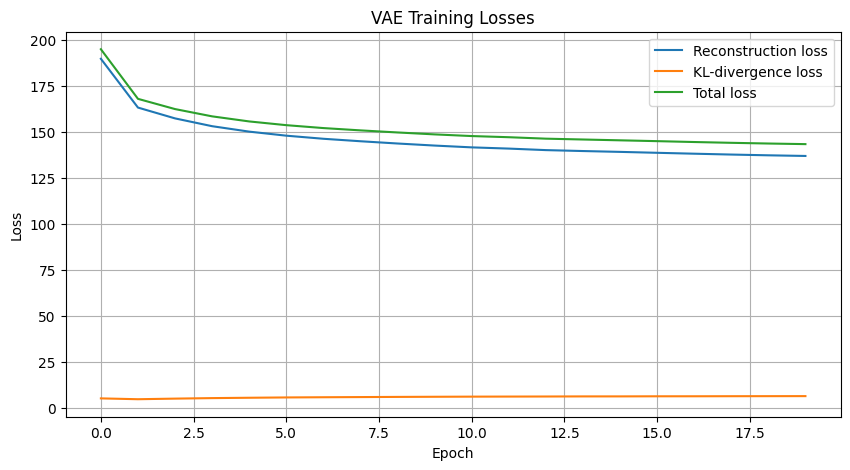

In [11]:

history_dict = history.history

plt.figure(figsize=(10, 5))
plt.plot(history_dict["reconstruction_loss"], label="Reconstruction loss")
plt.plot(history_dict["kl_loss"], label="KL-divergence loss")
plt.plot(history_dict["total_loss"], label="Total loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()



### How to read the loss graph

- **Reconstruction loss:** Lower values generally mean that the decoder is reproducing the input images more accurately.
- **KL-divergence loss:** Shows how strongly the latent distribution differs from the standard normal distribution.
- **Total loss:** The sum of the reconstruction and KL-divergence losses.

The losses may not decrease smoothly at every epoch because neural-network training is stochastic.


## 9. Reconstruct test images

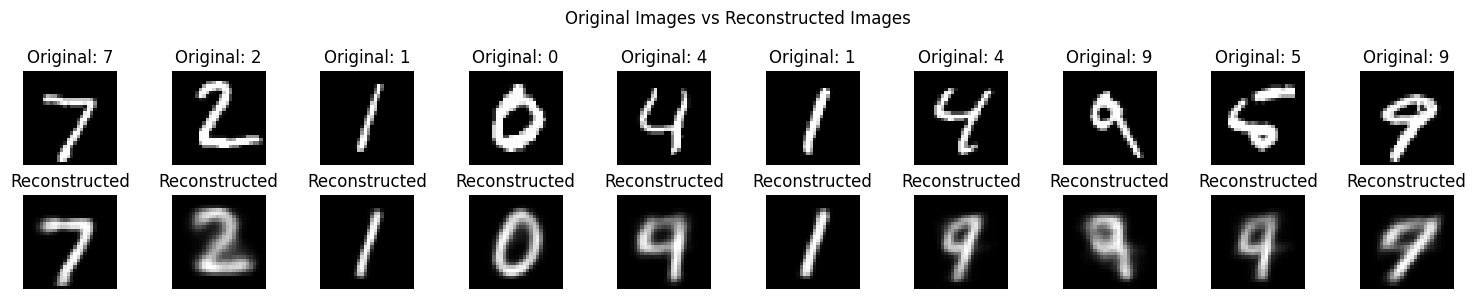

In [12]:

# Encode test images and reconstruct them using the decoder
z_mean_test, z_log_var_test = encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

# Use the mean vector for stable reconstruction
reconstructed_test = decoder.predict(z_mean_test, batch_size=BATCH_SIZE, verbose=0)

n = 10
plt.figure(figsize=(15, 3))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Original: {y_test[i]}")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_test[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Original Images vs Reconstructed Images")
plt.tight_layout()
plt.show()


## 10. Visualise the 2D latent space

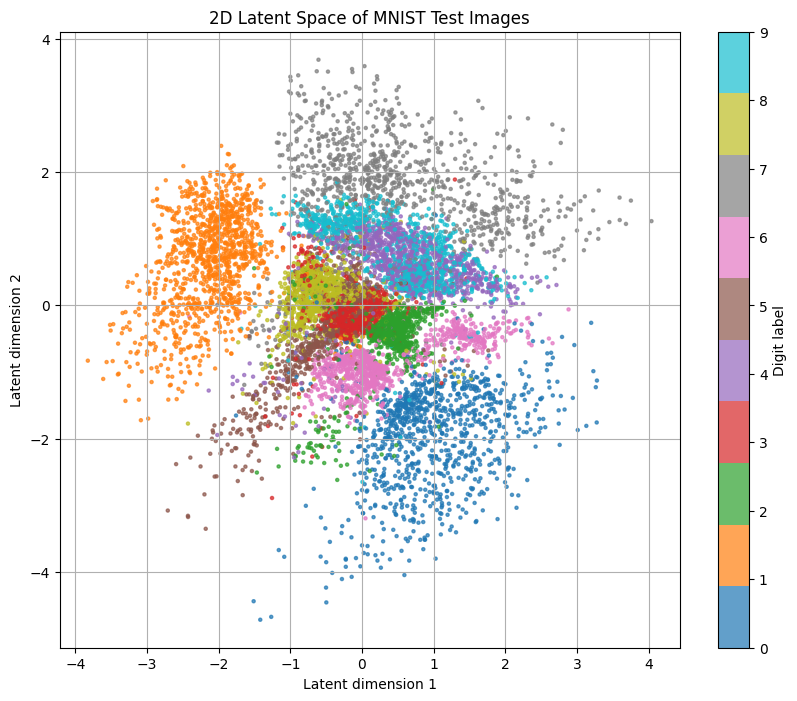

In [13]:

# z_mean_test has shape (number_of_test_images, 2)
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D Latent Space of MNIST Test Images")
plt.grid(True)
plt.show()



### What to examine in the scatter plot

Look for the following patterns:

- Do images of the same digit appear near one another?
- Are some digit groups overlapping?
- Are the digits arranged in clearly separated clusters?
- Which digits appear to have the most overlap?

Because the latent space is only two-dimensional, some overlap is expected.


## 11. Decode a grid of points across the latent space

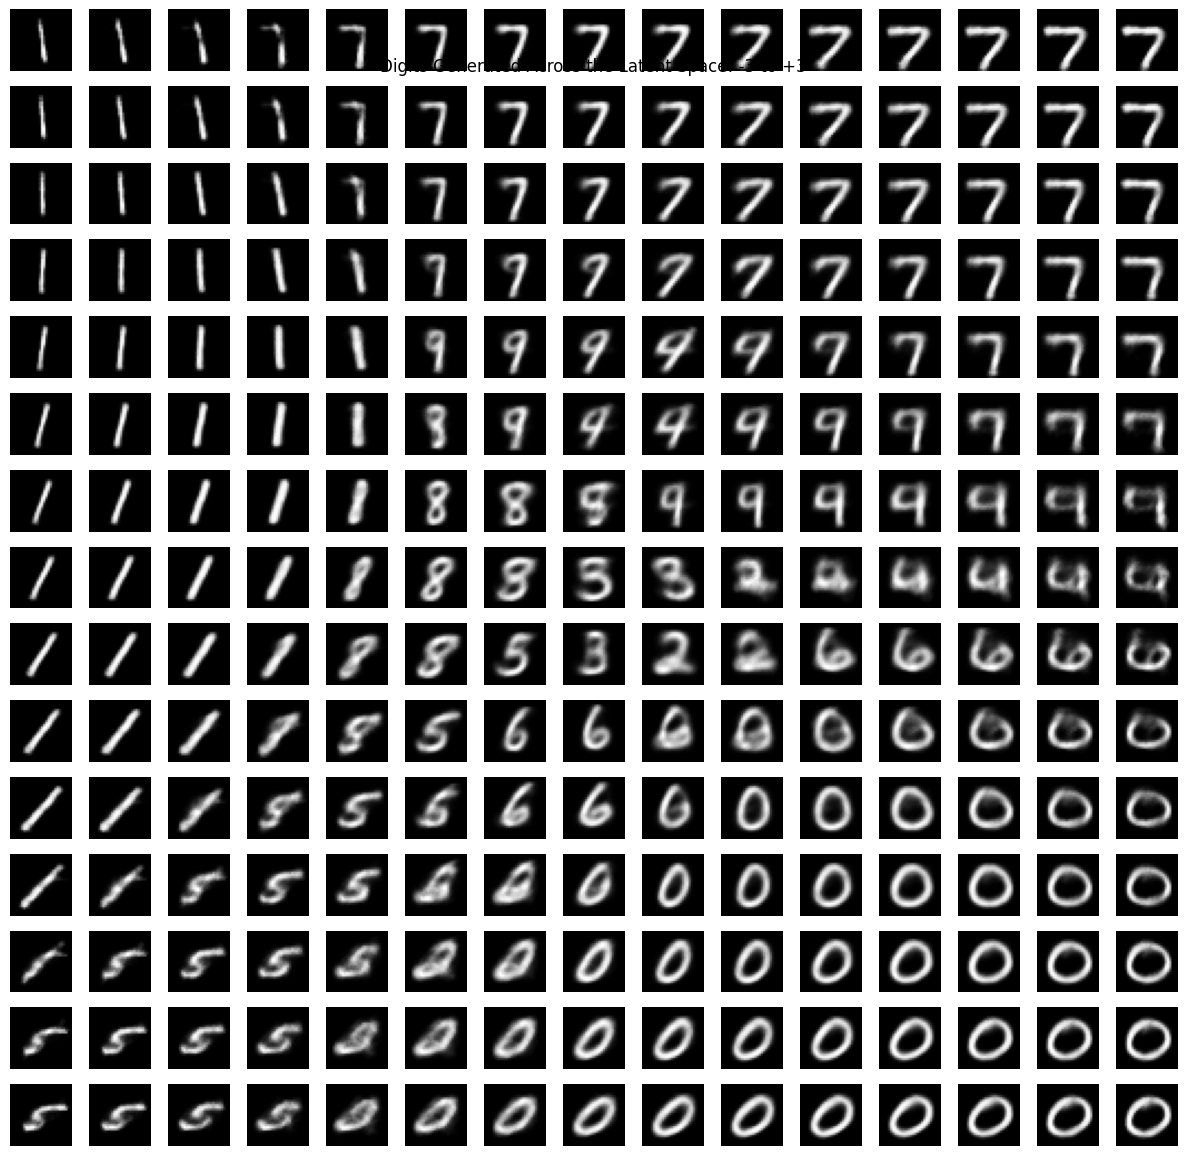

In [14]:

# Create a regular grid from -3 to +3 in the 2D latent space
grid_size = 15
latent_values = np.linspace(-3, 3, grid_size)

latent_grid = np.array([
    [x, y]
    for y in reversed(latent_values)
    for x in latent_values
], dtype="float32")

generated_images = decoder.predict(latent_grid, batch_size=BATCH_SIZE, verbose=0)

plt.figure(figsize=(12, 12))

for i, image in enumerate(generated_images):
    ax = plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Digits Generated Across the Latent Space: -3 to +3", y=0.92)
plt.tight_layout()
plt.show()


## 12. Generate images from selected extreme latent points

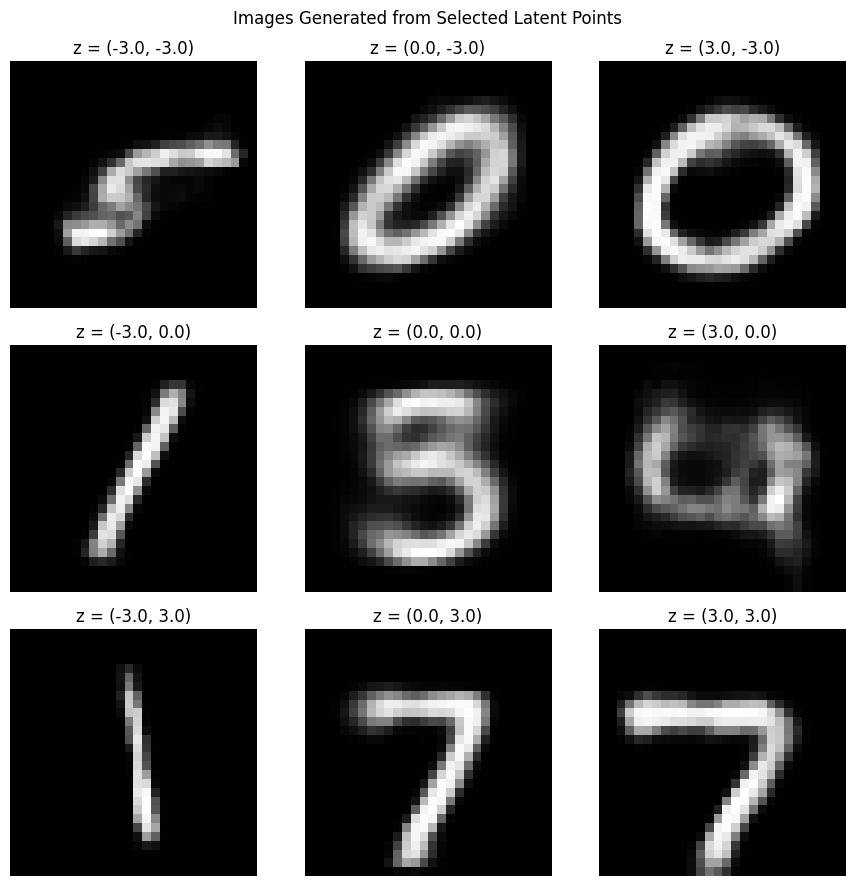

In [15]:

# Selected points include central, moderate, and extreme latent values
selected_points = np.array([
    [-3.0, -3.0],
    [ 0.0, -3.0],
    [ 3.0, -3.0],
    [-3.0,  0.0],
    [ 0.0,  0.0],
    [ 3.0,  0.0],
    [-3.0,  3.0],
    [ 0.0,  3.0],
    [ 3.0,  3.0],
], dtype="float32")

selected_images = decoder.predict(selected_points, verbose=0)

plt.figure(figsize=(9, 9))

for i, (point, image) in enumerate(zip(selected_points, selected_images)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"z = ({point[0]:.1f}, {point[1]:.1f})")
    plt.axis("off")

plt.suptitle("Images Generated from Selected Latent Points")
plt.tight_layout()
plt.show()



## 13. Short written observations

After running the notebook, complete or edit the following observations based on your actual plots.

### Observation 1: Do similar digits form clusters?

Digits with similar visual characteristics generally appear near one another in the 2D latent space. For example, some rounded digits may occupy nearby regions because the model learns shared visual features.

### Observation 2: Are the clusters clearly separated?

Some digit groups may be separated, but complete separation is not guaranteed. Similar-looking digits can overlap because the latent space is restricted to only two dimensions.

### Observation 3: How do generated digits change when moving through the latent space?

The generated digits gradually change their shape, thickness, angle, or other visual features as the latent coordinates change.

### Observation 4: Are the transitions smooth?

A well-trained VAE usually produces relatively smooth transitions between generated images. Small movements in the latent space should normally cause small visual changes rather than completely random changes.

### Final conclusion

The VAE learns a compact, probabilistic 2D representation of handwritten digits. The latent-space scatter plot helps us understand how the model organises digit classes, while the decoded grid shows how the decoder generates new images from different latent coordinates.
